In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('blogs.csv')
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [4]:
df.shape

(2000, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    2000 non-null   str  
 1   Labels  2000 non-null   str  
dtypes: str(2)
memory usage: 4.5 MB


# Data Exploration

In [6]:
df['Labels'].value_counts()

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

In [ ]:
# value_counts shows category distribution

# Text Cleaning

In [7]:
import re

In [8]:
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) 
    return text

df['cleaned_text'] = df['Data'].apply(clean_text)

# Remove Stopwords

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [10]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

# Feature Extraction

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text']).toarray()
y = df['Labels']

# Naive Bayes Model

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Model

In [15]:
from sklearn.naive_bayes import MultinomialNB

In [16]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
# Predictions

In [17]:
y_pred = model.predict(X_test)

# Evaluation

In [18]:
from sklearn.metrics import accuracy_score, classification_report

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.85
                          precision    recall  f1-score   support

             alt.atheism       0.56      0.83      0.67        18
           comp.graphics       0.71      0.83      0.77        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.84      0.84      0.84        25
   comp.sys.mac.hardware       0.87      0.95      0.91        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.80      0.89      0.84        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.95      1.00      0.97        19
         sci.electronics       0.65      0.69      0.67        16
                 sci.med       0.88      0.88      0.88     

# Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

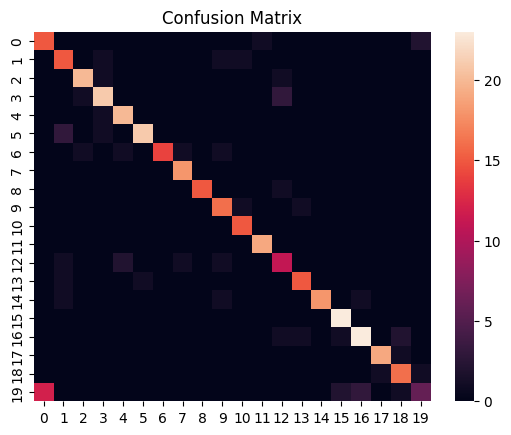

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=False)
plt.title("Confusion Matrix")
plt.show()

# Sentiment Analysis

In [22]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 24.4 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from textblob import TextBlob

In [24]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"
df['Sentiment'] = df['Data'].apply(get_sentiment)

# Sentiment Distribution

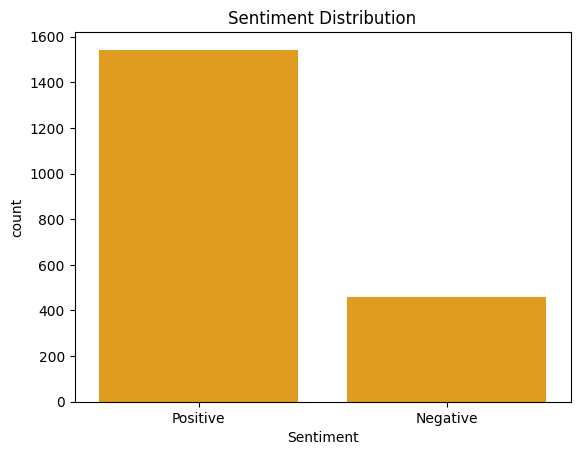

In [26]:
sns.countplot(x='Sentiment', data=df, color = "orange")
plt.title("Sentiment Distribution")
plt.show()

# Sentiment vs Category

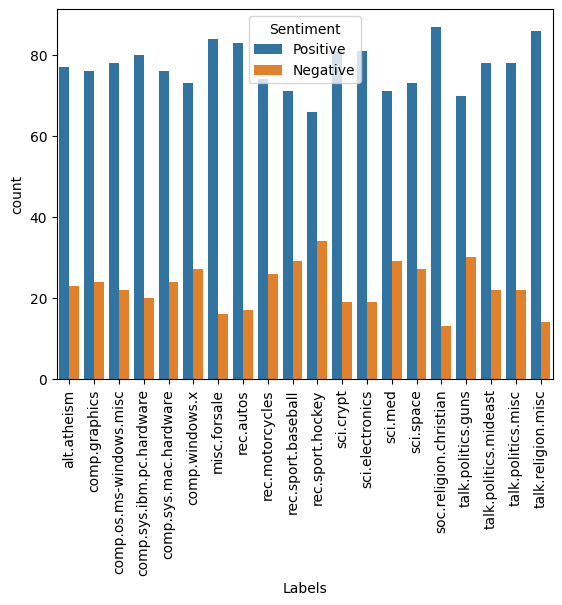

In [28]:
sns.countplot(x='Labels', hue='Sentiment', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
# The Naive Bayes classifier performed well in categorizing blog posts, achieving an accuracy of 85%. 
The model effectively learned patterns in the text using TF-IDF features.although Text data required cleaning and preprocessing

In [ ]:
# Naive Bayes is an effective and simple algorithm for text classification tasks. Combined with TF-IDF, it can efficiently handle large text datasets. 
Sentiment analysis provided additional insights into the emotional tone of blog posts.